# ResNet-18 CIFAR-10 Teacher vs Linear Students

Load saved probability artifacts for the CIFAR-10 test split and OOD datasets,
then compare teacher and student probability distributions for the saved student distillation methods.
Far-OOD groups MNIST and SVHN, while near-OOD corresponds to CIFAR-100.


In [11]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

sns.set_theme(style="darkgrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "runs").exists():
    ROOT = ROOT.parent

EXPERIMENT_NAME = "linear_student_resnet18_cifar10"
PROBABILITY_DIR = ROOT / "runs" / EXPERIMENT_NAME / "probabilities"
MANIFEST_PATH = PROBABILITY_DIR / "manifest.json"
CHECKPOINT = "best"

METHODS = {
    "mse_softmax": "MSE Softmax",
    "cross_entropy": "Cross-Entropy",
    "mse_logits": "MSE Logits",
}
DATASETS = {
    "cifar10_test": "ID: CIFAR-10 test",
    "mnist_test": "Far-OOD: MNIST test",
    "svhn_test": "Far-OOD: SVHN test",
    "cifar100_test": "Near-OOD: CIFAR-100 test",
}
DATASET_CLASS_NAMES = {
    "cifar10_test": [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    ],
    "mnist_test": [str(index) for index in range(10)],
    "svhn_test": [str(index) for index in range(10)],
    "cifar100_test": [str(index) for index in range(10)],
}

MANIFEST_PATH


PosixPath('/Users/bsh2022/Projects/distill-ood-detection/runs/linear_student_resnet18_cifar10/probabilities/manifest.json')

In [12]:
with MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    manifest = json.load(handle)

manifest["experiment_name"], manifest["checkpoint_selection"]


('linear_student_resnet18_cifar10', 'best')

In [13]:
def load_probability_artifact(path: str | Path) -> dict[str, object]:
    """Load one saved probability artifact on CPU."""

    artifact_path = Path(path)
    if not artifact_path.is_absolute():
        artifact_path = ROOT / artifact_path
    return torch.load(artifact_path, map_location="cpu", weights_only=False)


artifacts = []
for entry in manifest["artifacts"]:
    artifact = load_probability_artifact(entry["path"])
    artifacts.append({**artifact, **entry})

len(artifacts)


16

In [14]:
teacher_probabilities = {
    artifact["dataset"]: artifact
    for artifact in artifacts
    if artifact["model"] == "teacher"
}

student_probabilities = {
    (artifact["dataset"], artifact["method"], artifact["checkpoint"]): artifact
    for artifact in artifacts
    if artifact["model"] == "student"
}

available_methods = sorted(
    {
        artifact["method"]
        for artifact in artifacts
        if artifact["model"] == "student" and artifact["checkpoint"] == CHECKPOINT
    },
    key=list(METHODS).index,
)
available_datasets = sorted(
    teacher_probabilities,
    key=list(DATASETS).index,
)

if not available_methods:
    raise ValueError(
        f"No student probability artifacts found for checkpoint={CHECKPOINT!r} in {MANIFEST_PATH}."
    )

METHOD_ORDER = available_methods
DATASET_ORDER = [
    dataset_key
    for dataset_key in DATASETS
    if dataset_key in available_datasets
    and any(
        (dataset_key, method_key, CHECKPOINT) in student_probabilities
        for method_key in METHOD_ORDER
    )
]


def to_numpy(tensor: torch.Tensor) -> np.ndarray:
    """Move a tensor to CPU and convert it to a NumPy array."""

    return tensor.detach().cpu().numpy()


def build_argmax_heatmap(
    teacher_probs: np.ndarray,
    student_probs: np.ndarray,
    num_classes: int,
) -> np.ndarray:
    """Compute row-normalized teacher-vs-student argmax percentages."""

    teacher_argmax = teacher_probs.argmax(axis=1)
    student_argmax = student_probs.argmax(axis=1)

    counts = np.zeros((num_classes, num_classes), dtype=np.int64)
    np.add.at(counts, (teacher_argmax, student_argmax), 1)

    row_totals = counts.sum(axis=1, keepdims=True)
    return np.divide(
        counts * 100.0,
        row_totals,
        out=np.zeros_like(counts, dtype=float),
        where=row_totals > 0,
    )


def build_comparison(dataset_key: str, method_key: str) -> dict[str, object]:
    """Assemble teacher/student comparison data for one dataset and method."""

    teacher = teacher_probabilities[dataset_key]
    student = student_probabilities[(dataset_key, method_key, CHECKPOINT)]

    teacher_logits = to_numpy(teacher["logits"])
    student_logits = to_numpy(student["logits"])
    teacher_probs = to_numpy(teacher["probabilities"])
    student_probs = to_numpy(student["probabilities"])
    labels = to_numpy(teacher["labels"]).astype(int)
    sample_indices = np.arange(labels.shape[0])
    teacher_minus_student = teacher_probs - student_probs

    comparison = {
        "teacher_logits": teacher_logits,
        "student_logits": student_logits,
        "teacher_probs": teacher_probs,
        "student_probs": student_probs,
        "labels": labels,
        "predicted_values": pd.DataFrame(
            {
                "probability": np.concatenate(
                    [teacher_probs.ravel(), student_probs.ravel()]
                ),
                "model": ["Teacher"] * teacher_probs.size
                + ["Student"] * student_probs.size,
            }
        ),
        "max_probability_difference": teacher_probs.max(axis=1)
        - student_probs.max(axis=1),
        "argmax_agreement": build_argmax_heatmap(
            teacher_probs,
            student_probs,
            num_classes=teacher_probs.shape[1],
        ),
    }

    valid_label_mask = labels < teacher_probs.shape[1]
    if np.any(valid_label_mask):
        valid_labels = labels[valid_label_mask]
        valid_indices = sample_indices[valid_label_mask]
        class_names = DATASET_CLASS_NAMES[dataset_key]
        comparison["per_class_delta"] = pd.DataFrame(
            {
                "class_name": [class_names[label] for label in valid_labels],
                "teacher_minus_student": teacher_minus_student[
                    valid_indices, valid_labels
                ],
            }
        )

    return comparison


comparisons = {
    (method_key, dataset_key): build_comparison(dataset_key, method_key)
    for method_key in METHOD_ORDER
    for dataset_key in DATASET_ORDER
    if (dataset_key, method_key, CHECKPOINT) in student_probabilities
}


def dataset_group(dataset_key: str) -> str:
    """Map each dataset to the ID/far-OOD/near-OOD grouping used in the plots."""

    if dataset_key == "cifar10_test":
        return "ID"
    if dataset_key == "cifar100_test":
        return "Near-OOD"
    return "Far-OOD"


DISTRIBUTION_ORDER = ["ID", "Far-OOD", "Near-OOD"]
DISTRIBUTION_CLASS_NAMES = {
    "ID": DATASET_CLASS_NAMES["cifar10_test"],
    "Far-OOD": DATASET_CLASS_NAMES["mnist_test"],
    "Near-OOD": DATASET_CLASS_NAMES["cifar100_test"],
}


def build_probability_group_frame() -> pd.DataFrame:
    """Collect probability values into one dataframe by method and group."""

    probability_frames = []
    for (method_key, dataset_key), comparison in comparisons.items():
        probabilities = np.concatenate(
            [
                comparison["teacher_probs"].ravel(),
                comparison["student_probs"].ravel(),
            ]
        )
        probability_frames.append(
            pd.DataFrame(
                {
                    "probability": probabilities,
                    "distribution": dataset_group(dataset_key),
                    "dataset": DATASETS[dataset_key],
                    "method": METHODS[method_key],
                }
            )
        )

    return pd.concat(probability_frames, ignore_index=True)


def build_grouped_metric_frame(
    metric_key: str,
    value_name: str,
) -> pd.DataFrame:
    """Collect one comparison metric into a dataframe by method and group."""

    metric_frames = []
    for (method_key, dataset_key), comparison in comparisons.items():
        metric_frames.append(
            pd.DataFrame(
                {
                    value_name: comparison[metric_key],
                    "distribution": dataset_group(dataset_key),
                    "dataset": DATASETS[dataset_key],
                    "method": METHODS[method_key],
                }
            )
        )

    return pd.concat(metric_frames, ignore_index=True)


def build_grouped_argmax_heatmaps() -> dict[tuple[str, str], np.ndarray]:
    """Aggregate teacher-vs-student argmax agreement by method and group."""

    heatmaps = {}
    for method_key in METHOD_ORDER:
        for distribution in DISTRIBUTION_ORDER:
            grouped_comparisons = [
                comparison
                for (candidate_method_key, dataset_key), comparison in comparisons.items()
                if candidate_method_key == method_key
                and dataset_group(dataset_key) == distribution
            ]
            if not grouped_comparisons:
                continue
            teacher_probs = np.concatenate(
                [comparison["teacher_probs"] for comparison in grouped_comparisons],
                axis=0,
            )
            student_probs = np.concatenate(
                [comparison["student_probs"] for comparison in grouped_comparisons],
                axis=0,
            )
            heatmaps[(method_key, distribution)] = build_argmax_heatmap(
                teacher_probs,
                student_probs,
                num_classes=len(DISTRIBUTION_CLASS_NAMES[distribution]),
            )

    return heatmaps


def build_grouped_per_class_delta_frames() -> dict[tuple[str, str], pd.DataFrame]:
    """Aggregate ground-truth class deltas by method and group."""

    grouped_frames = {}
    for method_key in METHOD_ORDER:
        for distribution in DISTRIBUTION_ORDER:
            frames = [
                comparison["per_class_delta"]
                for (candidate_method_key, dataset_key), comparison in comparisons.items()
                if candidate_method_key == method_key
                and dataset_group(dataset_key) == distribution
                and "per_class_delta" in comparison
            ]
            if not frames:
                continue
            grouped_frames[(method_key, distribution)] = pd.concat(
                frames,
                ignore_index=True,
            )

    return grouped_frames


probability_group_frame = build_probability_group_frame()
max_probability_difference_group_frame = build_grouped_metric_frame(
    metric_key="max_probability_difference",
    value_name="max_probability_difference",
)
grouped_argmax_heatmaps = build_grouped_argmax_heatmaps()
grouped_per_class_delta_frames = build_grouped_per_class_delta_frames()

{
    "available_methods": [METHODS[method_key] for method_key in METHOD_ORDER],
    "available_datasets": [DATASETS[dataset_key] for dataset_key in DATASET_ORDER],
    "comparison_shapes": {
        (method_key, dataset_key): {
            "teacher_logits_shape": comparison["teacher_logits"].shape,
            "student_logits_shape": comparison["student_logits"].shape,
            "teacher_probs_shape": comparison["teacher_probs"].shape,
            "student_probs_shape": comparison["student_probs"].shape,
        }
        for (method_key, dataset_key), comparison in comparisons.items()
    },
}


{'available_methods': ['MSE Softmax', 'Cross-Entropy', 'MSE Logits'],
 'available_datasets': ['ID: CIFAR-10 test',
  'Far-OOD: MNIST test',
  'Far-OOD: SVHN test',
  'Near-OOD: CIFAR-100 test'],
 'comparison_shapes': {('mse_softmax',
   'cifar10_test'): {'teacher_logits_shape': (10000,
    10), 'student_logits_shape': (10000, 10), 'teacher_probs_shape': (10000,
    10), 'student_probs_shape': (10000, 10)},
  ('mse_softmax', 'mnist_test'): {'teacher_logits_shape': (10000, 10),
   'student_logits_shape': (10000, 10),
   'teacher_probs_shape': (10000, 10),
   'student_probs_shape': (10000, 10)},
  ('mse_softmax', 'svhn_test'): {'teacher_logits_shape': (26032, 10),
   'student_logits_shape': (26032, 10),
   'teacher_probs_shape': (26032, 10),
   'student_probs_shape': (26032, 10)},
  ('mse_softmax', 'cifar100_test'): {'teacher_logits_shape': (10000, 10),
   'student_logits_shape': (10000, 10),
   'teacher_probs_shape': (10000, 10),
   'student_probs_shape': (10000, 10)},
  ('cross_entropy'

The boxplots below compare the probability assigned to each sample's ground-truth class:
`p_teacher(y|x) - p_student(y|x)`.


Text(0.5, 0.98, 'Histogram of Predicted Probability Values')

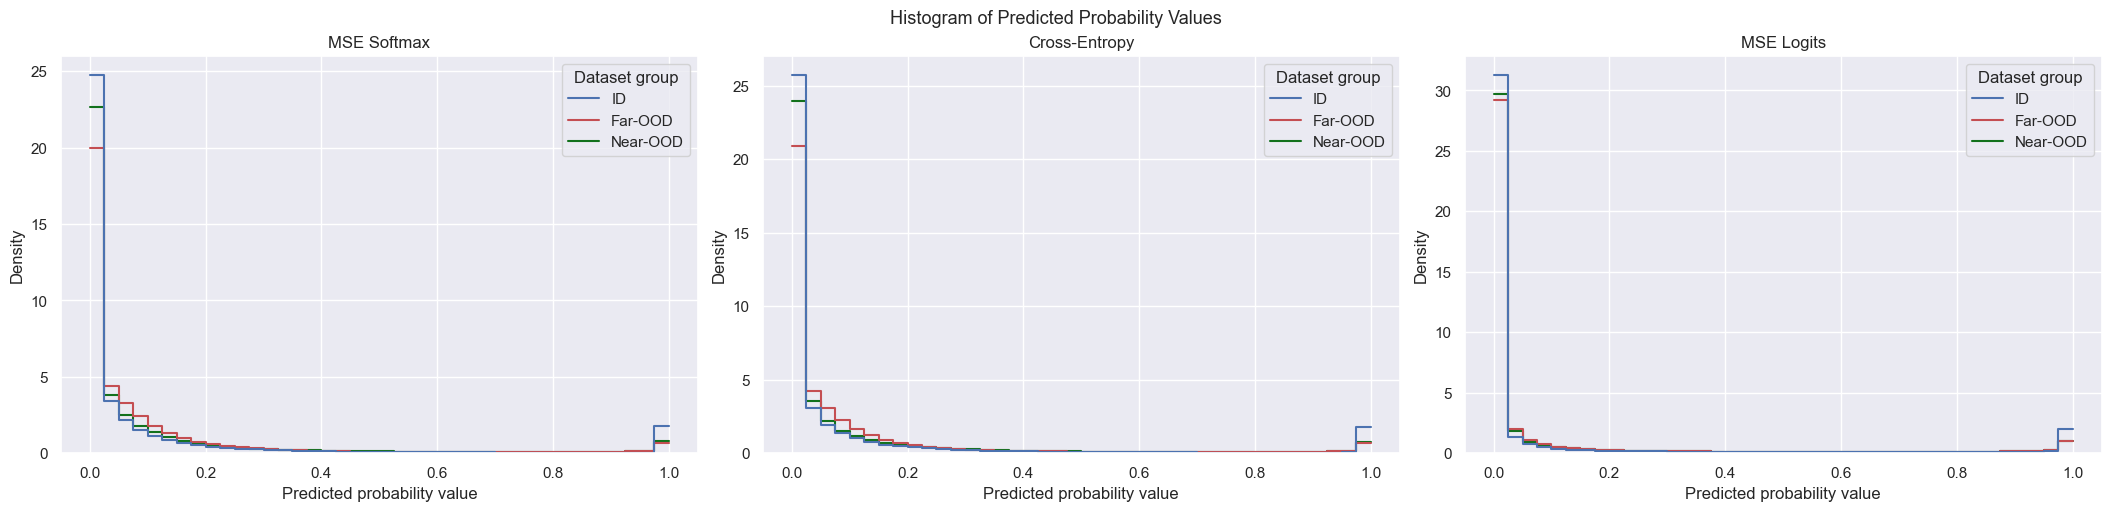

In [15]:
def make_axes_grid(
    figsize: tuple[int, int] | None = None,
) -> tuple[plt.Figure, np.ndarray]:
    """Create a grid with one subplot per available method."""

    method_count = len(METHOD_ORDER)
    ncols = method_count
    nrows = int(np.ceil(method_count / ncols))
    if figsize is None:
        figsize = (7 * ncols, 5 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[method_count:]:
        ax.set_visible(False)
    return fig, axes


probability_bins = np.linspace(0.0, 1.0, 41)

deep_palette = sns.color_palette("deep")
dark_palette = sns.color_palette("dark")
distribution_palette = {
    "ID": deep_palette[0],
    "Far-OOD": deep_palette[3],
    "Near-OOD": dark_palette[2],
}

fig, axes = make_axes_grid()
for axis_index, method_key in enumerate(METHOD_ORDER):
    ax = axes[axis_index]
    method_name = METHODS[method_key]
    method_frame = probability_group_frame.loc[
        probability_group_frame["method"] == method_name
    ]

    sns.histplot(
        data=method_frame,
        x="probability",
        hue="distribution",
        hue_order=DISTRIBUTION_ORDER,
        palette=distribution_palette,
        bins=probability_bins,
        common_bins=True,
        stat="density",
        element="step",
        fill=False,
        common_norm=False,
        ax=ax,
    )
    ax.set_title(method_name)
    ax.set_xlabel("Predicted probability value")
    ax.set_ylabel("Density")
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Dataset group")

fig.suptitle(
    "Histogram of Predicted Probability Values",
    fontsize=13,
)


Text(0.5, 0.98, 'Histogram of Teacher-Student Maximum Probability Differences')

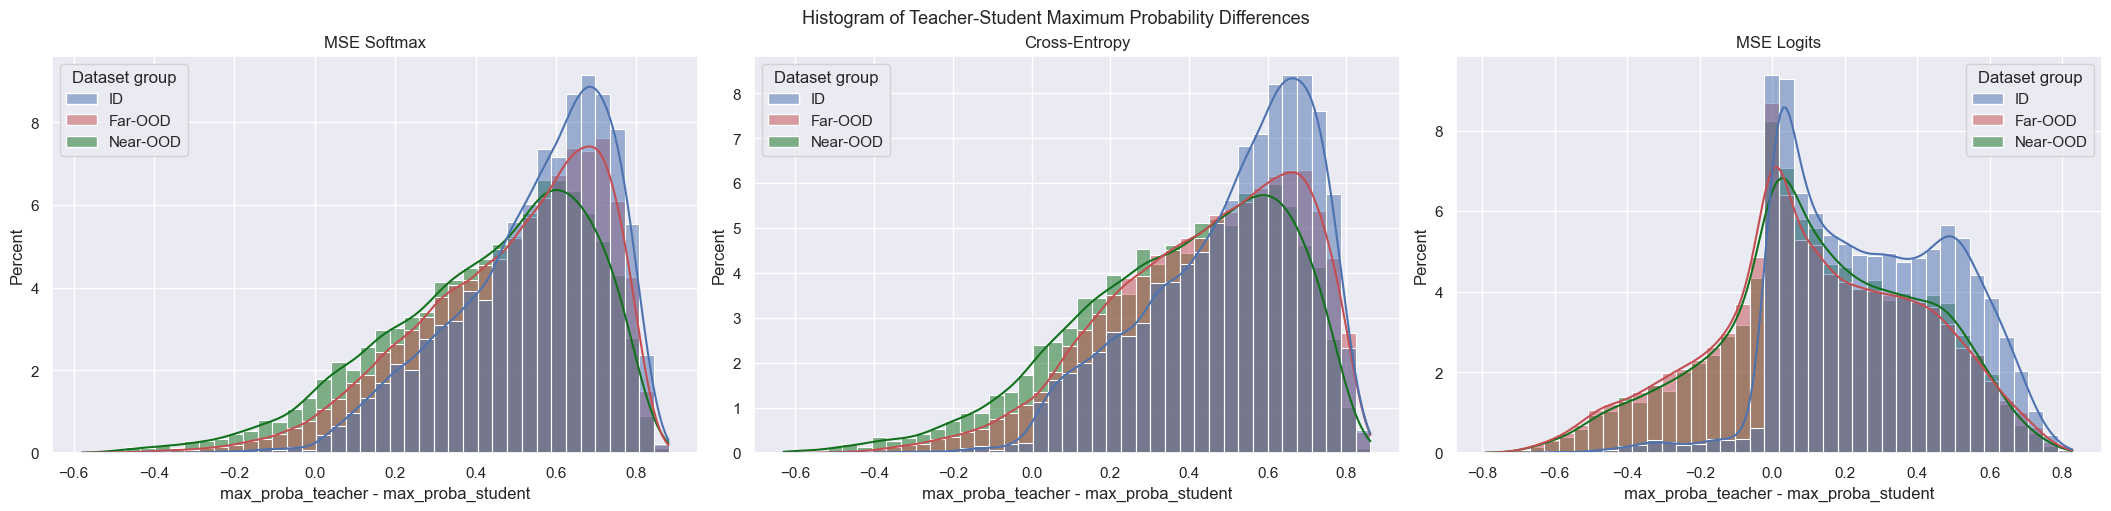

In [16]:
fig, axes = make_axes_grid()
for axis_index, method_key in enumerate(METHOD_ORDER):
    ax = axes[axis_index]
    method_name = METHODS[method_key]
    method_frame = max_probability_difference_group_frame.loc[
        max_probability_difference_group_frame["method"] == method_name
    ]

    sns.histplot(
        data=method_frame,
        x="max_probability_difference",
        hue="distribution",
        hue_order=DISTRIBUTION_ORDER,
        palette=distribution_palette,
        bins=40,
        kde=True,
        stat="percent",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(method_name)
    ax.set_xlabel("max_proba_teacher - max_proba_student")
    ax.set_ylabel("Percent")
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Dataset group")

fig.suptitle(
    "Histogram of Teacher-Student Maximum Probability Differences",
    fontsize=13,
)


Text(0.5, 0.98, 'Teacher vs Student Argmax Agreement Heatmap (%)')

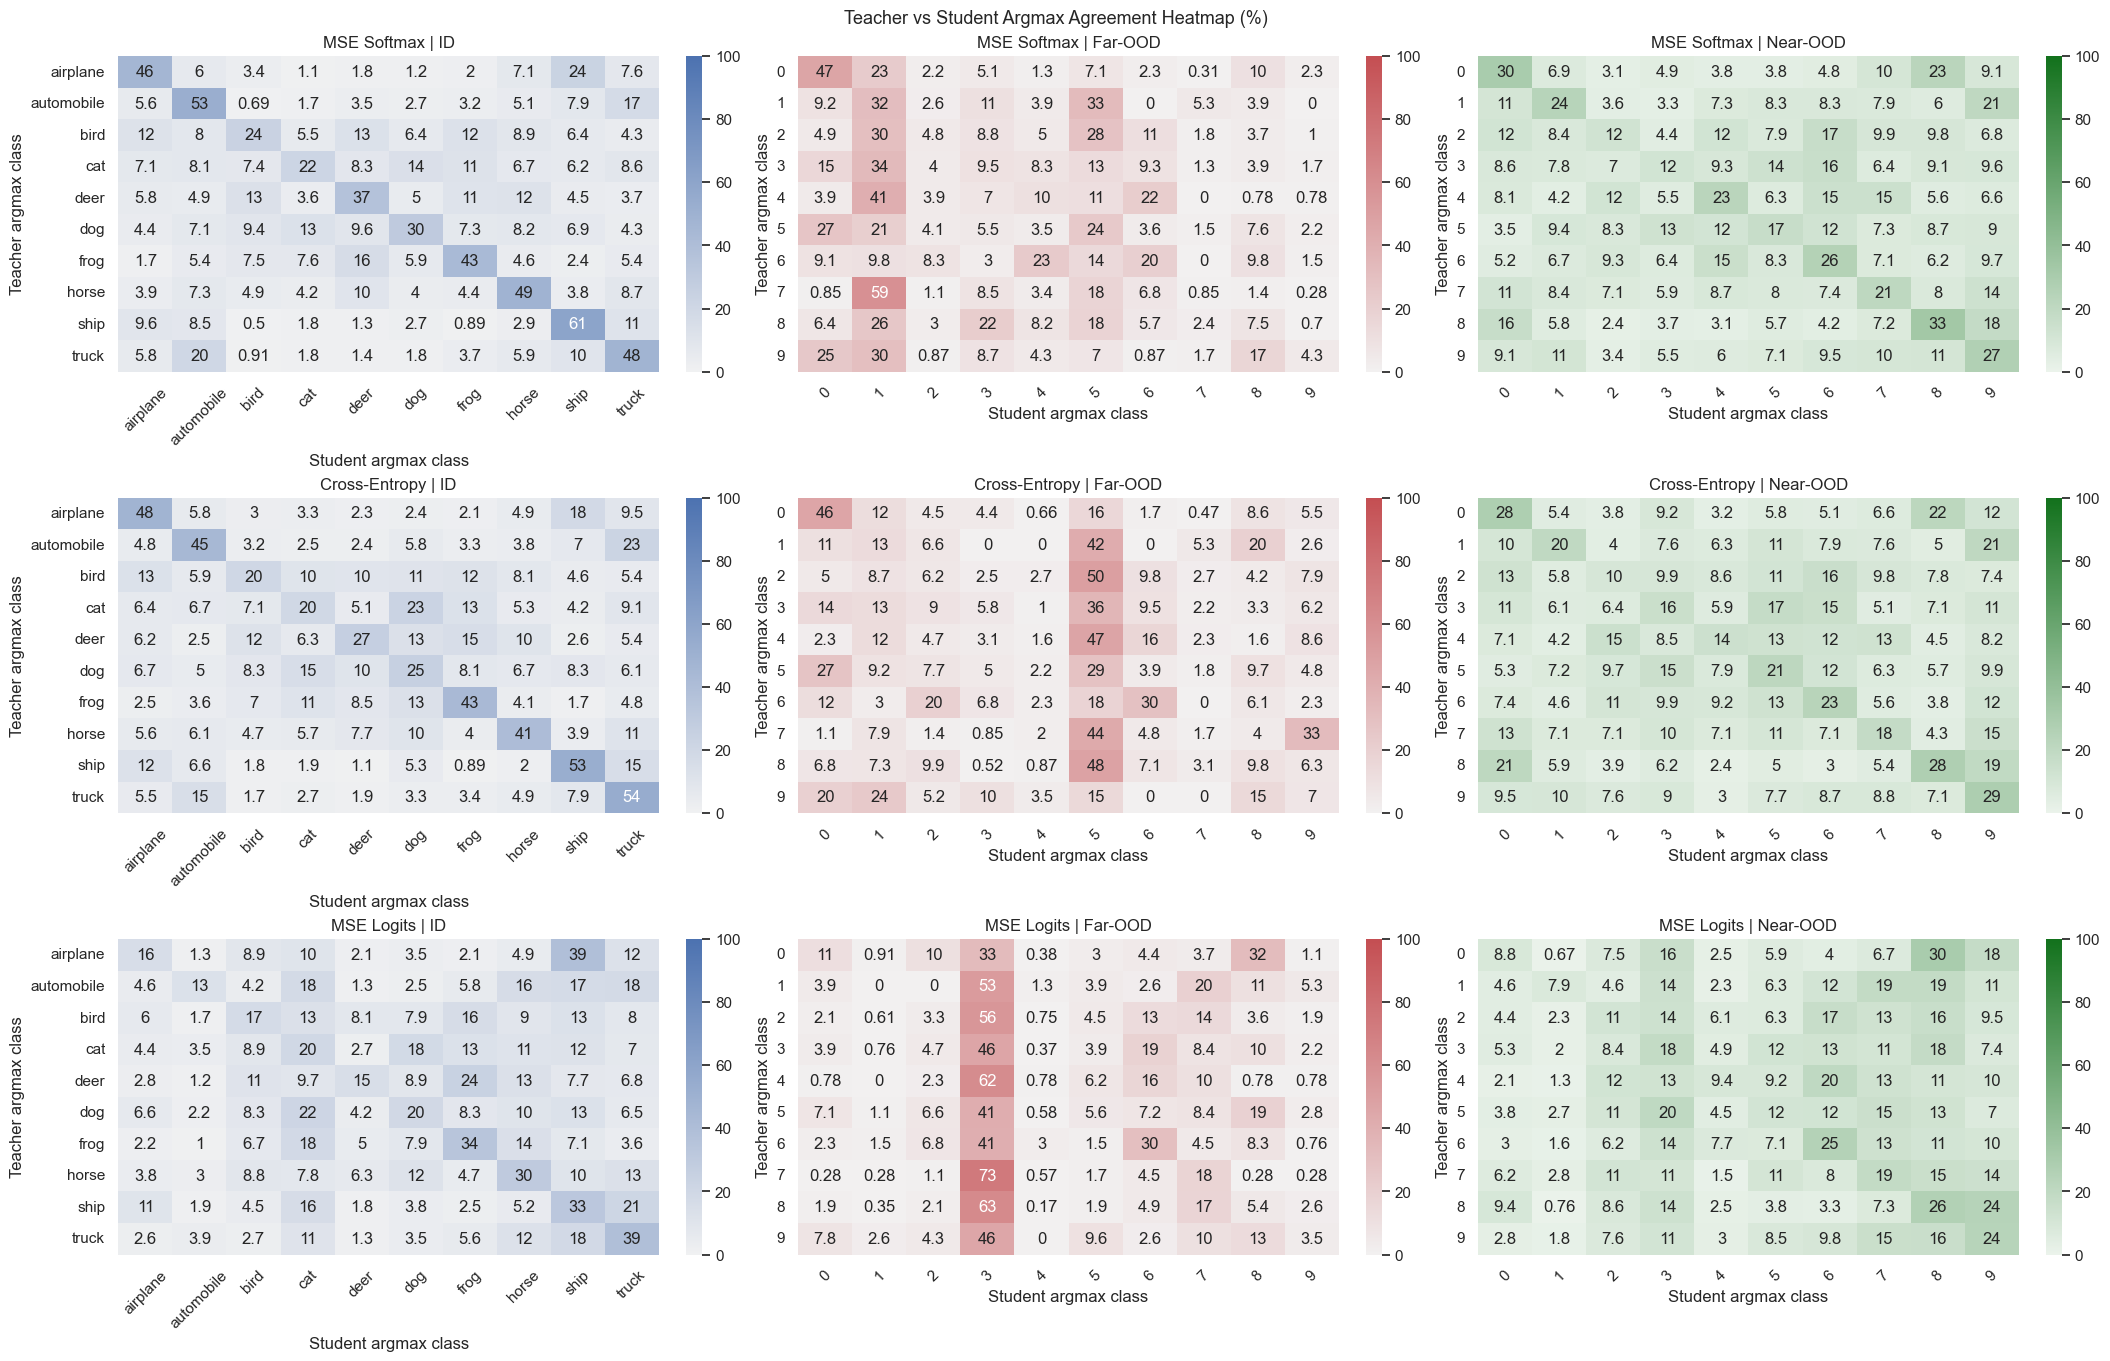

In [17]:
fig, axes = plt.subplots(
    len(METHOD_ORDER),
    len(DISTRIBUTION_ORDER),
    figsize=(21, 4.5 * len(METHOD_ORDER)),
    constrained_layout=True,
    squeeze=False,
)
distribution_cmaps = {
    distribution: sns.light_palette(
        distribution_palette[distribution],
        as_cmap=True,
    )
    for distribution in DISTRIBUTION_ORDER
}

for row_index, method_key in enumerate(METHOD_ORDER):
    for col_index, distribution in enumerate(DISTRIBUTION_ORDER):
        ax = axes[row_index, col_index]
        class_names = DISTRIBUTION_CLASS_NAMES[distribution]
        heatmap = grouped_argmax_heatmaps.get((method_key, distribution))
        if heatmap is None:
            ax.set_visible(False)
            continue

        sns.heatmap(
            heatmap,
            ax=ax,
            cmap=distribution_cmaps[distribution],
            vmin=0,
            vmax=100,
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True,
            annot=True,
        )
        ax.set_title(f"{METHODS[method_key]} | {distribution}")
        ax.set_xlabel("Student argmax class")
        ax.set_ylabel("Teacher argmax class")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Teacher vs Student Argmax Agreement Heatmap (%)",
    fontsize=13,
)


## ROC-AUC metrics

TODO: bug in the table, row corresponds to student, but should correspond to the variant (e.g. teacher MSP) 

In [18]:
import sys

from IPython.display import display

SRC_PATH = ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from distill_ood_detection.evaluation.ood_metrics import ood_detection_metrics

ID_DATASET_LABELS = {
    "cifar10_test": "CIFAR-10",
}
OOD_DATASET_LABELS = {
    "mnist_test": "Far-OOD: MNIST",
    "svhn_test": "Far-OOD: SVHN",
    "cifar100_test": "Near-OOD: CIFAR-100",
}
STUDENT_MODEL_NAME = "Linear"


def build_ood_metric_table() -> pd.DataFrame:
    """Build a ROC-AUC/FPR@95 summary table for each student method."""

    id_dataset_keys = [
        dataset_key for dataset_key in ID_DATASET_LABELS if dataset_key in DATASET_ORDER
    ]
    ood_dataset_keys = [
        dataset_key for dataset_key in OOD_DATASET_LABELS if dataset_key in DATASET_ORDER
    ]

    column_index = pd.MultiIndex.from_tuples(
        [
            (ID_DATASET_LABELS[id_dataset_key], OOD_DATASET_LABELS[ood_dataset_key])
            for id_dataset_key in id_dataset_keys
            for ood_dataset_key in ood_dataset_keys
        ],
        names=["ID dataset", "OOD dataset"],
    )
    row_index = pd.MultiIndex.from_tuples(
        [(STUDENT_MODEL_NAME, METHODS[method_key]) for method_key in METHOD_ORDER],
        names=["Student model", "Distillation method"],
    )
    metric_table = pd.DataFrame(index=row_index, columns=column_index, dtype=object)

    for method_key in METHOD_ORDER:
        for id_dataset_key in id_dataset_keys:
            id_artifact = teacher_probabilities[id_dataset_key]
            id_scores = to_numpy(id_artifact["probabilities"]).max(axis=1)

            for ood_dataset_key in ood_dataset_keys:
                ood_artifact = teacher_probabilities[ood_dataset_key]
                ood_scores = to_numpy(ood_artifact["probabilities"]).max(axis=1)

                labels = np.concatenate(
                    [
                        np.ones(id_scores.shape[0], dtype=int),
                        np.zeros(ood_scores.shape[0], dtype=int),
                    ]
                )
                scores = np.concatenate([id_scores, ood_scores])
                metrics = ood_detection_metrics(labels, scores)

                metric_table.loc[
                    (STUDENT_MODEL_NAME, METHODS[method_key]),
                    (
                        ID_DATASET_LABELS[id_dataset_key],
                        OOD_DATASET_LABELS[ood_dataset_key],
                    ),
                ] = (
                    f"{metrics['roc_auc']:.4f}/{metrics['fpr_at_95_tpr']:.4f}"
                )

    return metric_table


roc_auc_metric_table = build_ood_metric_table()
display(roc_auc_metric_table)


ID dataset                              CIFAR-10                 \
OOD dataset                       Far-OOD: MNIST  Far-OOD: SVHN   
Student model Distillation method                                 
Linear        MSE Softmax          0.9180/0.5564  0.9039/0.5983   
              Cross-Entropy        0.9180/0.5564  0.9039/0.5983   
              MSE Logits           0.9180/0.5564  0.9039/0.5983   

ID dataset                                             
OOD dataset                       Near-OOD: CIFAR-100  
Student model Distillation method                      
Linear        MSE Softmax               0.8790/0.6243  
              Cross-Entropy             0.8790/0.6243  
              MSE Logits                0.8790/0.6243

In [19]:
teacher_probabilities["cifar10_test"]


{'model': 'teacher',
 'dataset': 'cifar10_test',
 'split': 'test',
 'logits': tensor([[-2.4229, -1.1222, -0.4543,  ..., -2.9224, -2.1614, -2.6840],
         [-0.2070,  2.5973, -2.7122,  ..., -2.5841, 12.3438, -1.3333],
         [ 1.3407,  4.1562, -1.8017,  ..., -2.4846,  9.2058,  0.3646],
         ...,
         [-3.2296, -2.1898,  0.4131,  ...,  0.4185, -1.3627, -1.8564],
         [-1.6322,  9.0181,  0.7290,  ..., -1.5991, -0.2618, -2.2782],
         [-1.4727, -1.4150, -1.6301,  ..., 10.3886, -1.6609, -0.2062]]),
 'probabilities': tensor([[1.3132e-07, 4.8222e-07, 9.4038e-07,  ..., 7.9692e-08, 1.7057e-07,
          1.0115e-07],
         [3.5418e-06, 5.8499e-05, 2.8923e-07,  ..., 3.2876e-07, 9.9993e-01,
          1.1484e-06],
         [3.8125e-04, 6.3676e-03, 1.6463e-05,  ..., 8.3160e-06, 9.9305e-01,
          1.4365e-04],
         ...,
         [4.2428e-07, 1.2001e-06, 1.6205e-05,  ..., 1.6293e-05, 2.7441e-06,
          1.6749e-06],
         [2.3678e-05, 9.9934e-01, 2.5109e-04,  ..., 2.